In [1]:
import os

base_dir = "/Users/jakobwerkgarner/code/mt_dsnow"
os.chdir(base_dir)

import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import xarray as xr

import model_diff.model_diff_helpers as mdh

In [2]:
# Load example Dataset

example_dsnow = xr.open_dataset("model_diff/R_comparisson/output/batch_comparison_output/netcdf_with_obs/Holzgau_dsnow_allseasons_with_obs.nc")

example_hs2swe  = xr.open_dataset("model_diff/R_comparisson/output/batch_comparison_output/netcdf_with_obs/Holzgau_hs2swe_allseasons_with_obs.nc")

# Transform example_hs2swe so it has the same variables (names + units intent) as example_dsnow
src = example_hs2swe

hs_m = src["HS_layer_cm"] / 100.0
swe_layers = hs_m * src["RHO"]  # SWE per layer (mm w.e.) from layer thickness (m) and density (kg/m^3)

example_hs2swe = xr.Dataset(
    data_vars={
        "HS": hs_m.transpose("layer", "dos", "season"),
        "SWE_layers": swe_layers.transpose("layer", "dos", "season"),
        "AGE": src["AGE"].transpose("layer", "dos", "season"),
        "RHO": src["RHO"].transpose("layer", "dos", "season"),
        "OVB": src["OVB"].transpose("layer", "dos", "season"),
        "SWE_total": src["SWE_mm"].transpose("dos", "season"),
        "HS_meas_m": (src["HS_obs_cm"] / 100.0).transpose("dos", "season"),
        "SWE_obs_mm": src["SWE_obs_mm"].transpose("dos", "season"),
    },
    coords={
        "season": src["season"],
        "dos": src["dos"],
        "layer": src["layer"],
    },
    attrs=src.attrs,
)

# Enforce exact variable order as example_dsnow
example_hs2swe = example_hs2swe[list(example_dsnow.data_vars)]
example_hs2swe


<xarray.Dataset> Size: 4MB
Dimensions:     (layer: 39, dos: 182, season: 15)
Coordinates:
  * season      (season) int32 60B 1998 1999 2000 2001 ... 2009 2010 2011 2012
  * dos         (dos) int32 728B 1 2 3 4 5 6 7 8 ... 176 177 178 179 180 181 182
  * layer       (layer) int32 156B 1 2 3 4 5 6 7 8 9 ... 32 33 34 35 36 37 38 39
Data variables:
    HS          (layer, dos, season) float64 852kB nan 0.0 0.0 ... nan nan nan
    SWE_layers  (layer, dos, season) float64 852kB nan nan nan ... nan nan nan
    AGE         (layer, dos, season) float64 852kB ...
    RHO         (layer, dos, season) float64 852kB ...
    OVB         (layer, dos, season) float64 852kB ...
    SWE_total   (dos, season) float64 22kB ...
    HS_meas_m   (dos, season) float64 22kB nan 0.0 0.0 0.0 ... 0.0 0.0 0.0 0.0
    SWE_obs_mm  (dos, season) float64 22kB ...
Attributes:
    season_window_start_mmdd:  11-01
    season_window_end_mmdd:    04-30
    dos_definition:            dos = 1 corresponds to Nov 1 of (season-1); do...

(<Figure size 1200x600 with 2 Axes>,
 <Axes: title={'center': 'Stacked snow layers colored by RHO'}, xlabel='dos', ylabel='HS'>)

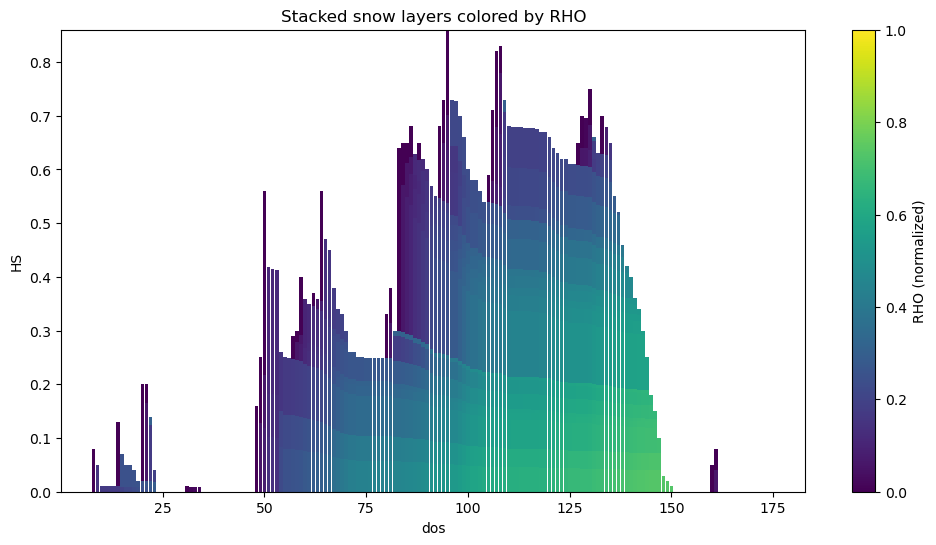

In [3]:
mdh.plot_layer_stack(example_hs2swe.sel(season = 2005), var="RHO", norm = True)

/Users/jakobwerkgarner/miniforge3/envs/MT_dsnow/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


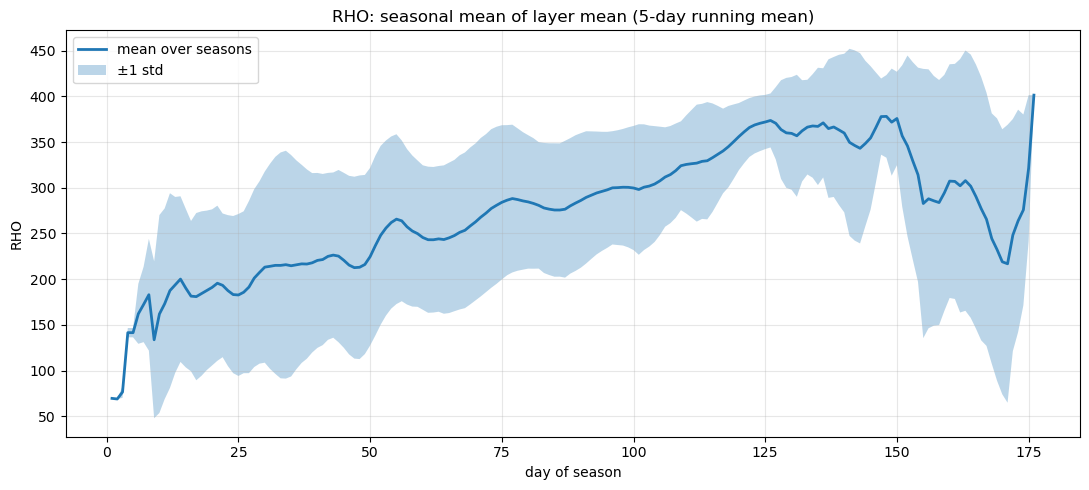

/Users/jakobwerkgarner/miniforge3/envs/MT_dsnow/lib/python3.12/site-packages/numpy/lib/_nanfunctions_impl.py:2019: RuntimeWarning: Degrees of freedom <= 0 for slice.
  var = nanvar(a, axis=axis, dtype=dtype, out=out, ddof=ddof,


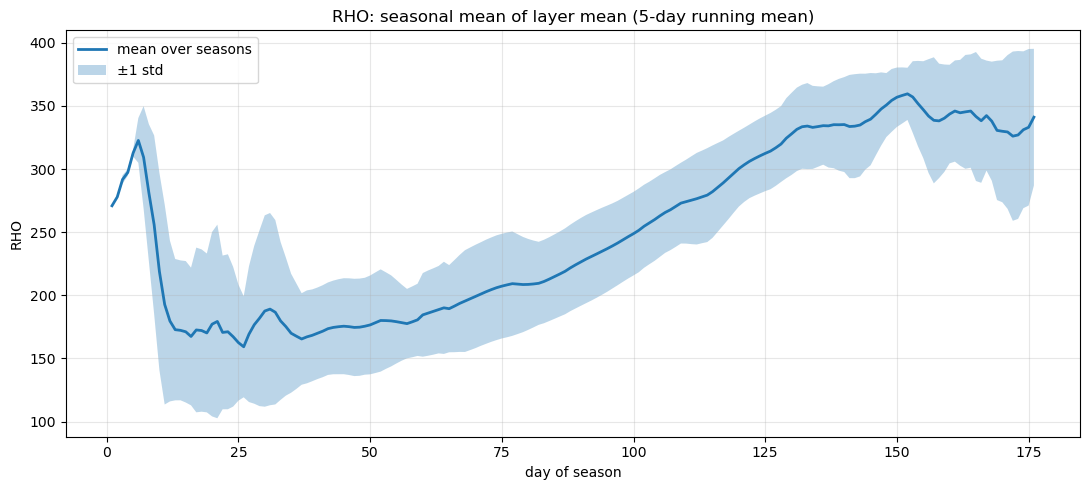

In [4]:
# 3) Mean over seasons of the layer sum, with std shading
mdh.plot_var_seasons("RHO", mode="season_mean_layer_mean", ds=example_dsnow, spread="std", running_mean=5)

# 4) Mean over seasons of the layer mean, with IQR shading
mdh.plot_var_seasons("RHO", mode="season_mean_layer_mean", ds=example_hs2swe, spread="std", running_mean=5)

# Caluclate the differnce of the SWE between eeach layer between one and the next day


In [5]:
# Day-to-day layer-wise SWE change (current day - previous day) along dos
for ds in (example_dsnow, example_hs2swe):
    dSWE = ds["SWE_layers"] - ds["SWE_layers"].shift(dos=1)
    ds["dSWE"] = dSWE

    # Split into gain/loss components (loss as positive magnitude)
    ds["SWE_gain"] = dSWE.where(dSWE > 0, 0).where(dSWE.notnull())
    ds["SWE_loss"] = (-dSWE.where(dSWE < 0, 0)).where(dSWE.notnull())

    ds["dSWE"].attrs["long_name"] = "Daily change in layer SWE"
    ds["dSWE"].attrs["description"] = "SWE_layers(dos) - SWE_layers(dos-1); first dos is NaN"

    ds["SWE_gain"].attrs["long_name"] = "Daily SWE gain per layer"
    ds["SWE_gain"].attrs["description"] = "max(dSWE, 0); first dos is NaN"

    ds["SWE_loss"].attrs["long_name"] = "Daily SWE loss per layer"
    ds["SWE_loss"].attrs["description"] = "max(-dSWE, 0); first dos is NaN"

    if "units" in ds["SWE_layers"].attrs:
        units = ds["SWE_layers"].attrs["units"]
        ds["dSWE"].attrs["units"] = units
        ds["SWE_gain"].attrs["units"] = units
        ds["SWE_loss"].attrs["units"] = units



In [6]:
for ds in (example_dsnow, example_hs2swe):
    for var in ("SWE_gain", "SWE_loss", "dSWE"):
        ds[var] = ds[var].fillna(0)

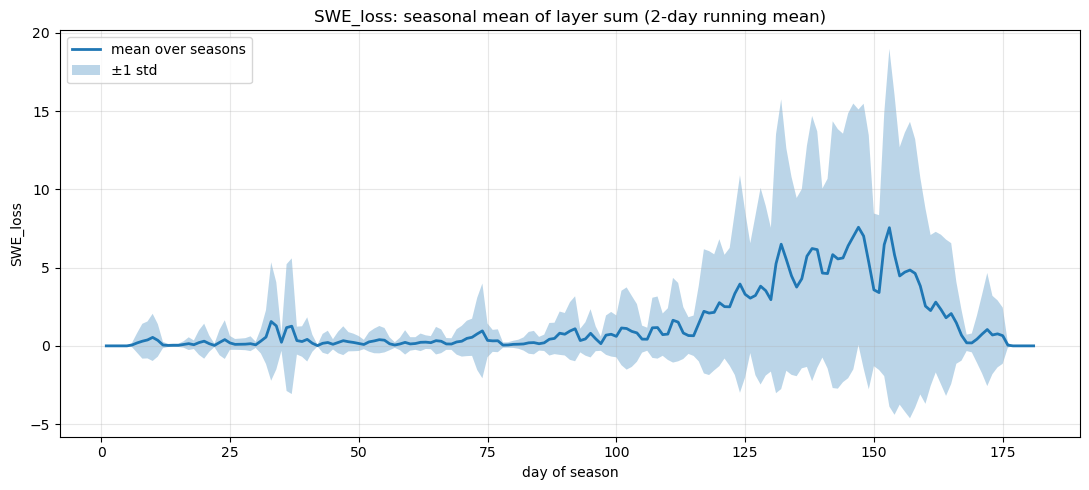

In [7]:
mdh.plot_var_seasons("SWE_loss", mode="season_mean_layer_sum", ds=example_dsnow, spread="std", running_mean=2)

dsnow seasonal SWE loss integral (mean ± std): 265.69 ± 124.87
hs2swe seasonal SWE loss integral (mean ± std): 292.73 ± 128.47


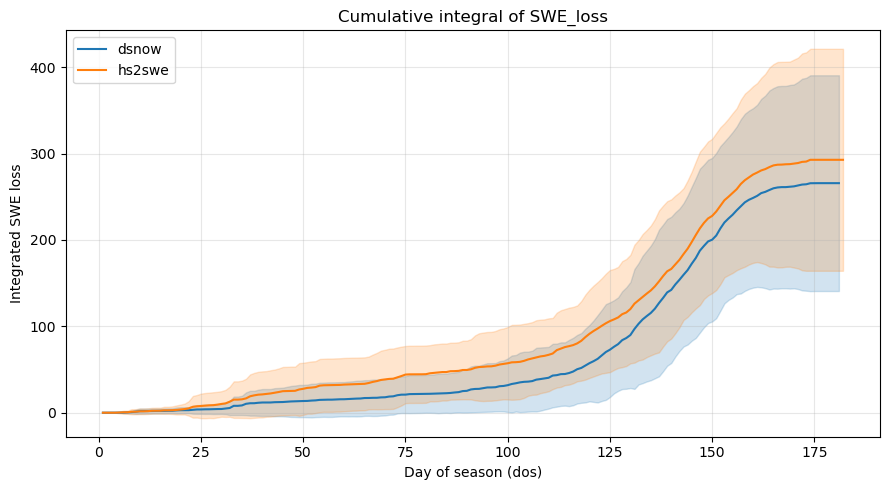

In [8]:
# Integrate SWE loss over layers and time, then plot cumulative seasonal integral

for _ds in (example_dsnow, example_hs2swe):
    # layer-integrated daily SWE loss (per dos, per season)
    _ds["SWE_loss_layer_int"] = _ds["SWE_loss"].sum(dim="layer", skipna=True)

    # cumulative integral over dos (season progress)
    _ds["SWE_loss_cum_int"] = _ds["SWE_loss_layer_int"].cumsum(dim="dos")

# Plot mean cumulative integral across seasons with ±1 std
fig, ax = plt.subplots(figsize=(9, 5))

for label, _ds, color in [
    ("dsnow", example_dsnow, "tab:blue"),
    ("hs2swe", example_hs2swe, "tab:orange"),
]:
    m = _ds["SWE_loss_cum_int"].mean(dim="season")
    s = _ds["SWE_loss_cum_int"].std(dim="season")

    ax.plot(_ds["dos"], m, label=label, color=color)
    ax.fill_between(_ds["dos"].values, (m - s).values, (m + s).values, color=color, alpha=0.2)

    seasonal_total = _ds["SWE_loss_layer_int"].sum(dim="dos")
    print(f"{label} seasonal SWE loss integral (mean ± std): "
          f"{float(seasonal_total.mean()):.2f} ± {float(seasonal_total.std()):.2f}")

ax.set_title("Cumulative integral of SWE_loss")
ax.set_xlabel("Day of season (dos)")
ax.set_ylabel("Integrated SWE loss")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

(<Figure size 1200x600 with 2 Axes>,
 <Axes: title={'center': 'Stacked snow layers colored by dSWE'}, xlabel='dos', ylabel='HS'>)

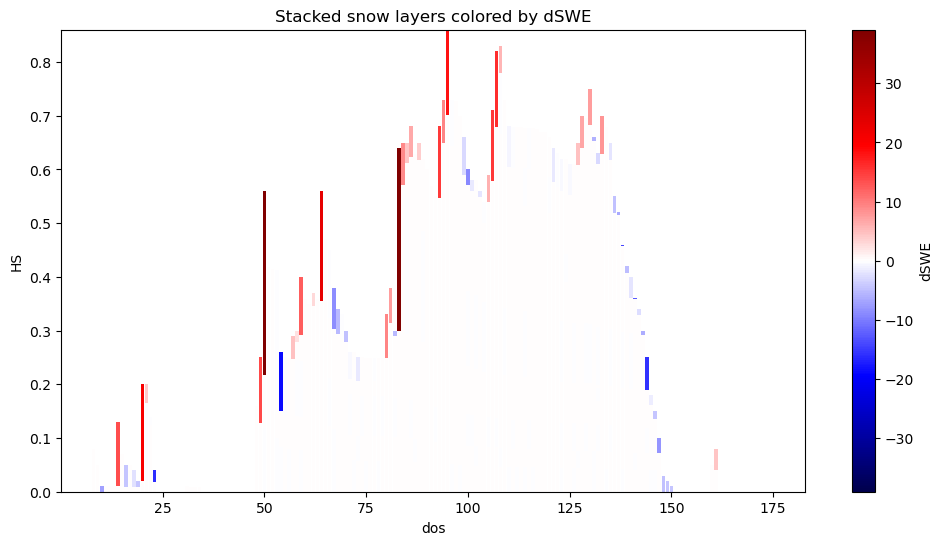

In [9]:
mdh.plot_layer_stack(example_hs2swe.sel(season = 2005), var= "dSWE", cmap= "seismic", centered_cmap= True)

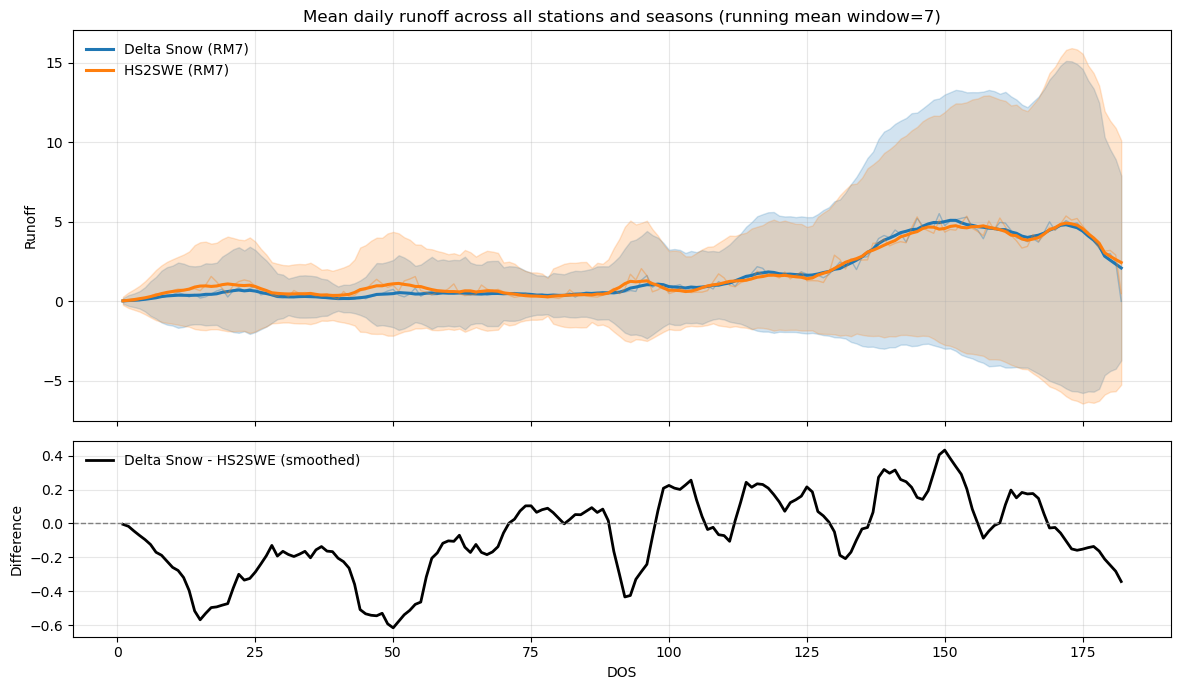

         total_runoff_mean  total_runoff_std  n_station_season
dataset                                                       
dsnow           300.770096        145.296633               394
hs2swe          313.196977        140.586882               396
Paired station-season samples for difference box: 390


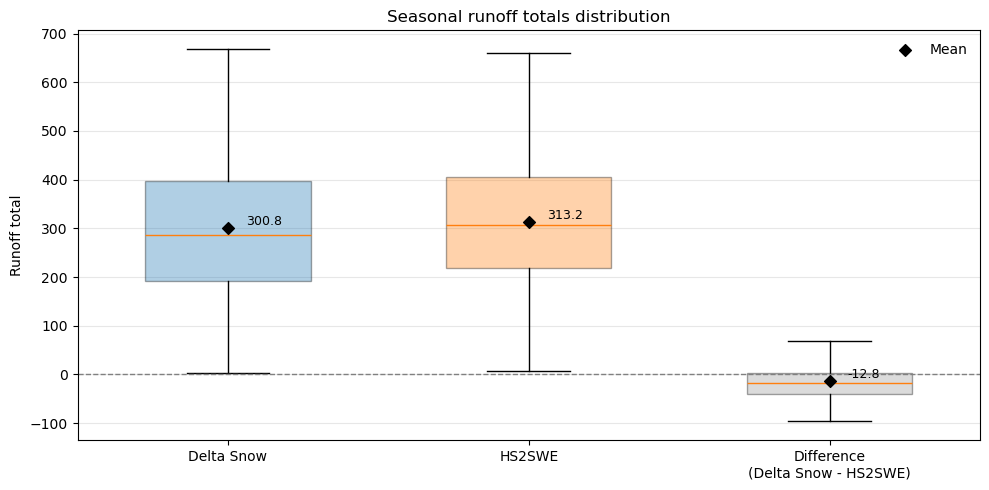

In [12]:
# Mean daily runoff across all stations and all seasons from all NetCDF files in the folder
# + adjustable running mean + boxplot for each model and their difference

nc_dir = "/Users/jakobwerkgarner/code/mt_dsnow/model_diff/R_comparisson/output/HS_SWE_by_station/allseason_all_station/netcdf_with_obs"
nc_files = sorted(
    os.path.join(nc_dir, f) for f in os.listdir(nc_dir) if f.endswith(".nc")
)

# Adjustable smoothing window (set to 1 to disable smoothing)
runmean_window = 7

def _infer_dataset_label(path, attrs):
    txt = " ".join(
        [
            os.path.basename(path).lower(),
            str(attrs.get("title", "")).lower(),
            str(attrs.get("model", "")).lower(),
            str(attrs.get("source", "")).lower(),
        ]
    )
    if "hs2swe" in txt:
        return "hs2swe"
    if any(k in txt for k in ["delta snow", "deltasnow", "delta_snow", "dsnow"]):
        return "dsnow"
    return None

def _running_mean(s, win):
    win = max(1, int(win))
    return s.rolling(window=win, center=True, min_periods=1).mean()

def _canonical_station_id(station_name):
    s = station_name.lower()
    for suf in ["_allseasons_with_obs", "_with_obs"]:
        if s.endswith(suf):
            s = s[: -len(suf)]
    for tok in ["_dsnow", "_hs2swe"]:
        while s.endswith(tok):
            s = s[: -len(tok)]
    return s

daily_rows_all = []
skipped_files = []

for fp in nc_files:
    with xr.open_dataset(fp) as dsi:
        label = _infer_dataset_label(fp, dsi.attrs)
        if label is None:
            skipped_files.append((os.path.basename(fp), "label not found"))
            continue

        if "SWE_layers" in dsi.data_vars:
            swe = dsi["SWE_layers"]
        elif {"HS_layer_cm", "RHO"}.issubset(set(dsi.data_vars)):
            swe = (dsi["HS_layer_cm"] / 100.0) * dsi["RHO"]
        elif "SWE_mm" in dsi.data_vars:
            swe = dsi["SWE_mm"]
        else:
            skipped_files.append((os.path.basename(fp), "no SWE variable"))
            continue

        if "dos" not in swe.dims:
            skipped_files.append((os.path.basename(fp), "no dos dim"))
            continue

        dSWE_local = swe - swe.shift(dos=1)
        SWE_loss_local = (-dSWE_local.where(dSWE_local < 0, 0)).fillna(0)

        runoff_daily_local = (
            SWE_loss_local.sum(dim="layer", skipna=True)
            if "layer" in SWE_loss_local.dims
            else SWE_loss_local
        )

        ddf_local = runoff_daily_local.to_dataframe(name="runoff").reset_index()
        keep = [c for c in ["dos", "season", "runoff"] if c in ddf_local.columns]
        ddf_local = ddf_local[keep].copy()
        if "season" not in ddf_local.columns:
            ddf_local["season"] = np.nan

        station_raw = os.path.splitext(os.path.basename(fp))[0]
        ddf_local["dataset"] = label
        ddf_local["station"] = station_raw
        ddf_local["station_pair"] = _canonical_station_id(station_raw)
        daily_rows_all.append(ddf_local)

if not daily_rows_all:
    raise ValueError("No usable files found.")

all_daily_df = pd.concat(daily_rows_all, ignore_index=True)

daily_mean_all = (
    all_daily_df.groupby(["dataset", "dos"], as_index=False)["runoff"]
    .agg(mean_runoff="mean", std_runoff="std", n="count")
    .fillna({"std_runoff": 0.0})
    .sort_values(["dataset", "dos"])
)

daily_mean_all["mean_runoff_rm"] = (
    daily_mean_all.groupby("dataset", group_keys=False)["mean_runoff"]
    .apply(lambda s: _running_mean(s, runmean_window))
)
daily_mean_all["std_runoff_rm"] = (
    daily_mean_all.groupby("dataset", group_keys=False)["std_runoff"]
    .apply(lambda s: _running_mean(s, runmean_window))
)

fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(12, 7), sharex=True, gridspec_kw={"height_ratios": [2, 1]}
)

style = {
    "dsnow": ("Delta Snow", "tab:blue"),
    "hs2swe": ("HS2SWE", "tab:orange"),
}

for key in ["dsnow", "hs2swe"]:
    sub = daily_mean_all[daily_mean_all["dataset"] == key].sort_values("dos")
    if sub.empty:
        continue
    label_txt, color = style[key]

    ax1.plot(sub["dos"], sub["mean_runoff"], lw=1.0, color=color, alpha=0.35)
    ax1.plot(
        sub["dos"], sub["mean_runoff_rm"], lw=2.2, color=color,
        label=f"{label_txt} (RM{runmean_window})"
    )
    ax1.fill_between(
        sub["dos"].values,
        (sub["mean_runoff_rm"] - sub["std_runoff_rm"]).values,
        (sub["mean_runoff_rm"] + sub["std_runoff_rm"]).values,
        color=color,
        alpha=0.2,
    )

ax1.set_title(f"Mean daily runoff across all stations and seasons (running mean window={runmean_window})")
ax1.set_ylabel("Runoff")
ax1.grid(alpha=0.3)
ax1.legend(frameon=False)

# Explicitly compute and plot diff_mean from smoothed daily means
p_mean = (
    daily_mean_all.pivot_table(index="dos", columns="dataset", values="mean_runoff", aggfunc="mean")
    .sort_index()
)
diff_mean = pd.Series(dtype=float, name="diff_mean")

if {"dsnow", "hs2swe"}.issubset(p_mean.columns):
    common = p_mean[["dsnow", "hs2swe"]].dropna(how="any")
    if not common.empty:
        p_mean_rm = common.rolling(window=max(1, int(runmean_window)), center=True, min_periods=1).mean()
        diff_mean = (p_mean_rm["dsnow"] - p_mean_rm["hs2swe"]).rename("diff_mean")
        ax2.plot(
            diff_mean.index.values,
            diff_mean.values,
            color="black",
            lw=2.0,
            label="Delta Snow - HS2SWE (smoothed)"
        )
        ax2.legend(frameon=False)
    else:
        ax2.text(0.5, 0.5, "No overlapping DOS for diff_mean", ha="center", va="center", transform=ax2.transAxes)

ax2.axhline(0, color="gray", lw=1, ls="--")
ax2.set_xlabel("DOS")
ax2.set_ylabel("Difference")
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Seasonal totals per station-season
seasonal_totals_all = (
    all_daily_df.groupby(["dataset", "station_pair", "season"], as_index=False)["runoff"].sum()
)

print(
    seasonal_totals_all.groupby("dataset")["runoff"]
    .agg(total_runoff_mean="mean", total_runoff_std="std", n_station_season="count")
)

# Boxplot for both models + paired difference
season_pivot = seasonal_totals_all.pivot_table(
    index=["station_pair", "season"], columns="dataset", values="runoff", aggfunc="mean"
)

s_ds = season_pivot["dsnow"].dropna() if "dsnow" in season_pivot.columns else pd.Series(dtype=float)
s_hs = season_pivot["hs2swe"].dropna() if "hs2swe" in season_pivot.columns else pd.Series(dtype=float)
s_diff = (
    (season_pivot["dsnow"] - season_pivot["hs2swe"]).dropna()
    if {"dsnow", "hs2swe"}.issubset(season_pivot.columns)
    else pd.Series(dtype=float)
)

print(f"Paired station-season samples for difference box: {len(s_diff)}")

box_series, box_labels, box_colors = [], [], []
if not s_ds.empty:
    box_series.append(s_ds)
    box_labels.append("Delta Snow")
    box_colors.append("tab:blue")
if not s_hs.empty:
    box_series.append(s_hs)
    box_labels.append("HS2SWE")
    box_colors.append("tab:orange")
if not s_diff.empty:
    box_series.append(s_diff)
    box_labels.append("Difference\n(Delta Snow - HS2SWE)")
    box_colors.append("0.6")

fig_box, axb = plt.subplots(figsize=(10, 5))

if box_series:
    bp = axb.boxplot(
        box_series,
        tick_labels=box_labels,
        showfliers=False,
        patch_artist=True,
        widths=0.55,
    )

    for patch, c in zip(bp["boxes"], box_colors):
        patch.set_facecolor(c)
        patch.set_alpha(0.35)

    means = [s.mean() if len(s) else np.nan for s in box_series]
    xpos = np.arange(1, len(means) + 1)
    axb.scatter(xpos, means, marker="D", color="black", s=36, zorder=3, label="Mean")
    for x, m in zip(xpos, means):
        if np.isfinite(m):
            axb.text(x + 0.06, m, f"{m:.1f}", fontsize=9, va="bottom")

    axb.legend(frameon=False)
else:
    axb.text(0.5, 0.5, "No data available for boxplot", ha="center", va="center", transform=axb.transAxes)

axb.axhline(0, color="gray", lw=1, ls="--")
axb.set_title("Seasonal runoff totals distribution")
axb.set_ylabel("Runoff total")
axb.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

if skipped_files:
    print("\nSkipped files:")
    for fn, reason in skipped_files:
        print(f"- {fn}: {reason}")